In [1]:
import glob
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from optimal_market_maker_exchange_contract_drl import (
    Market,
    MarketMaker,
    plot_controls,
)

%matplotlib inline

In [2]:
MODEL_NAME = "model"

PROJ_DIR = Path.cwd().parent
MODELS_DIR = PROJ_DIR / "saved_models" / "market_maker"
MODEL_DIR = MODELS_DIR / "keep" / MODEL_NAME

print(f"Loading from: {MODEL_DIR}")
print(f"Contents:     {[p.name for p in sorted(MODEL_DIR.iterdir())]}")

Loading from: c:\Users\chris\VSCodeProjects\optimal-market-maker-exchange-contract-drl\saved_models\market_maker\keep\model
Contents:     ['checkpoint_epoch_10000.pt', 'controls_2.0_0.05_-150.png', 'controls_2.0_0.05_-50.png', 'controls_2.0_0.05_0.png', 'controls_2.0_0.05_150.png', 'controls_2.0_0.05_50.png', 'loss.png', 'market_cfg.json', 'market_maker_cfg.json', 'train_cfg.json', 'training.log']


In [3]:
with open(MODEL_DIR / "market_cfg.json") as f:
    market_cfg = json.load(f)
with open(MODEL_DIR / "market_maker_cfg.json") as f:
    mm_cfg = json.load(f)
with open(MODEL_DIR / "train_cfg.json") as f:
    train_cfg = json.load(f)

batch_size = train_cfg["batch_size"]
z_bar = train_cfg["z_bar"]
device = torch.device("cpu")

market = Market(**market_cfg, batch_size=batch_size)
market.to(device)

mm = MarketMaker(market=market, mm_cfg=mm_cfg, batch_size=batch_size)
mm.to(device)

# Load latest checkpoint
ckpts = sorted(
    glob.glob(str(MODEL_DIR / "checkpoint_epoch_*.pt")),
    key=lambda p: int(Path(p).stem.replace("checkpoint_epoch_", "")),
)
latest = Path(ckpts[-1])
epochs_trained, _, losses = mm.load(path=latest, device=device)
mm.eval()

print(f"Loaded checkpoint: {latest.name}  ({epochs_trained} epochs)")

Loaded checkpoint: checkpoint_epoch_10000.pt  (10000 epochs)


In [4]:
plot_q = 50  # inventory
plot_z_d = 0.05  # dark pool incentive (fixed for both sides)
n_points = 400

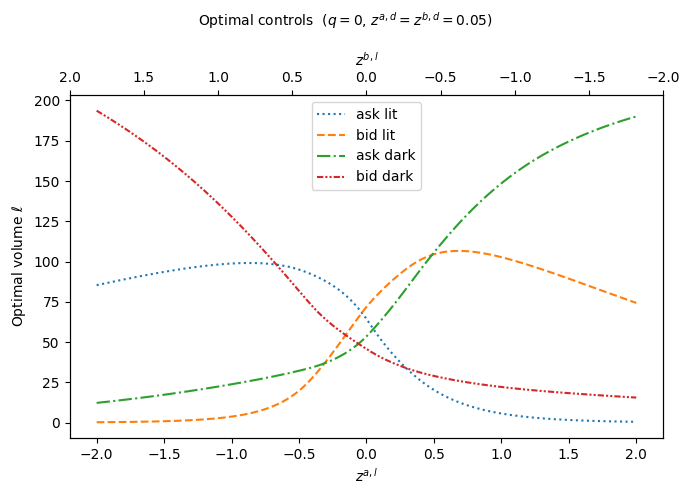

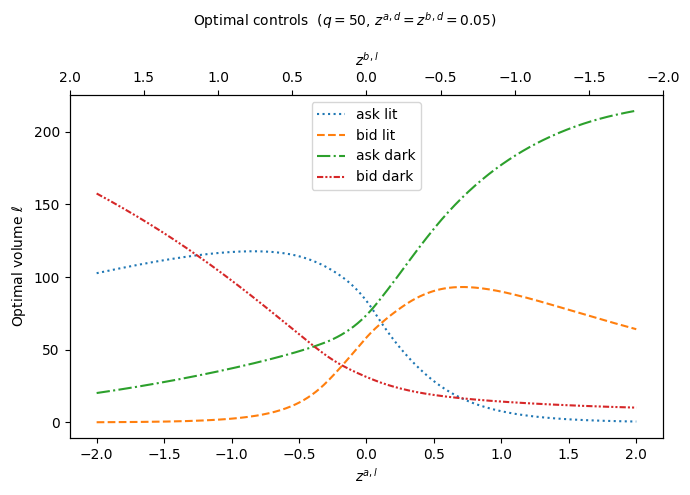

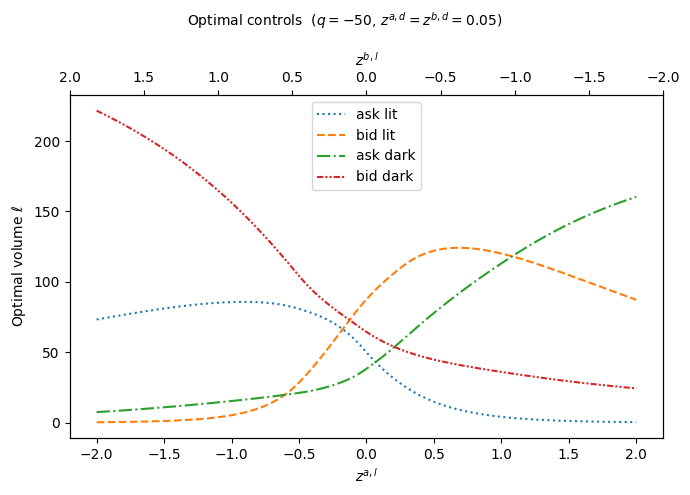

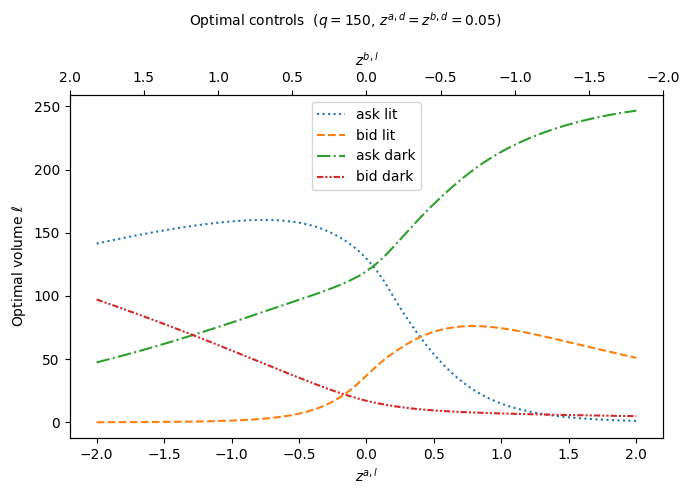

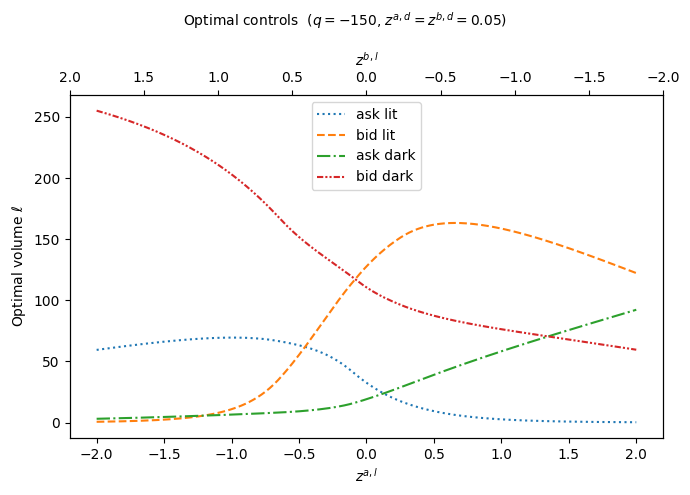

In [5]:
for q_val in [0, 50, -50, 150, -150]:
    fig_path = MODEL_DIR / f"controls_{z_bar}_{plot_z_d}_{q_val}.png"
    fig = plot_controls(mm, z_bar, plot_q=q_val, plot_z_d=0.05, save_path=fig_path)
    plt.show()